Importing libraries and loading the files into pandas dataframes

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import json



septemberDAM = pd.read_json('septemberDAMJSON.json')
octoberDAM = pd.read_json('octoberDAMJSON.json')
septemberIDM = pd.read_json('septemberIDMJSON.json')
octoberIDM = pd.read_json('octoberIDMJSON.json')


Changing the date format and its timezone to match Bratislava

In [3]:
#changing date format
septemberDAM['deliveryDay'] = pd.to_datetime(septemberDAM['deliveryDay'])
septemberDAM['deliveryStart'] = pd.to_datetime(septemberDAM['deliveryStart'])
septemberDAM['deliveryEnd'] = pd.to_datetime(septemberDAM['deliveryEnd'])

octoberDAM['deliveryDay'] = pd.to_datetime(octoberDAM['deliveryDay'])
octoberDAM['deliveryStart'] = pd.to_datetime(octoberDAM['deliveryStart'])
octoberDAM['deliveryEnd'] = pd.to_datetime(octoberDAM['deliveryEnd'])

septemberIDM['deliveryDay'] = pd.to_datetime(septemberIDM['deliveryDay'])
septemberIDM['deliveryStart'] = pd.to_datetime(septemberIDM['deliveryStart'])
septemberIDM['deliveryEnd'] = pd.to_datetime(septemberIDM['deliveryEnd'])

octoberIDM['deliveryDay'] = pd.to_datetime(octoberIDM['deliveryDay'])
octoberIDM['deliveryStart'] = pd.to_datetime(octoberIDM['deliveryStart'])
octoberIDM['deliveryEnd'] = pd.to_datetime(octoberIDM['deliveryEnd'])

In [4]:
#changing the timezone
septemberDAM['deliveryDayBA'] = septemberDAM["deliveryDay"].dt.tz_localize("Europe/Bratislava")
septemberDAM['deliveryStartBA'] = septemberDAM["deliveryStart"].dt.tz_convert("Europe/Bratislava")
septemberDAM['deliveryEndBA'] = septemberDAM["deliveryEnd"].dt.tz_convert("Europe/Bratislava")

octoberDAM['deliveryDayBA'] = octoberDAM["deliveryDay"].dt.tz_localize("Europe/Bratislava")
octoberDAM['deliveryStartBA'] = octoberDAM["deliveryStart"].dt.tz_convert("Europe/Bratislava")
octoberDAM['deliveryEndBA'] = octoberDAM["deliveryEnd"].dt.tz_convert("Europe/Bratislava")

septemberIDM['deliveryDayBA'] = septemberIDM["deliveryDay"].dt.tz_localize("Europe/Bratislava")
septemberIDM['deliveryStartBA'] = septemberIDM["deliveryStart"].dt.tz_convert("Europe/Bratislava")
septemberIDM['deliveryEndBA'] = septemberIDM["deliveryEnd"].dt.tz_convert("Europe/Bratislava")

octoberIDM['deliveryDayBA'] = octoberIDM["deliveryDay"].dt.tz_localize("Europe/Bratislava")
octoberIDM['deliveryStartBA'] = octoberIDM["deliveryStart"].dt.tz_convert("Europe/Bratislava")
octoberIDM['deliveryEndBA'] = octoberIDM["deliveryEnd"].dt.tz_convert("Europe/Bratislava")


Correlation between DAM and IDM

In [5]:
mergedS = pd.merge(
    septemberDAM[['deliveryStartBA', 'price']],
    septemberIDM[['deliveryStartBA', 'priceWeightedAverage']],
    on='deliveryStartBA',
    how='inner'
).rename(columns={'price': 'DAM_price', 'priceWeightedAverage': 'IDM_price'})

octoberDAM['deliveryHour'] = octoberDAM['deliveryStart'].dt.floor('h')
octoberDAM['deliveryHour'] = octoberDAM["deliveryHour"].dt.tz_convert("Europe/Bratislava")

octoberDAM_hourly = (
    octoberDAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

mergedOhourly = pd.merge(
    octoberDAM_hourly,
    octoberIDM[['deliveryStartBA', 'priceWeightedAverage']],
    on='deliveryStartBA',
    how='inner'
).rename(columns={'price': 'DAM_price', 'priceWeightedAverage': 'IDM_price'})

print("September")
print(mergedS[['DAM_price', 'IDM_price']].corr())
print("")
print("October")
print(mergedOhourly[['DAM_price', 'IDM_price']].corr())


September
           DAM_price  IDM_price
DAM_price   1.000000   0.916037
IDM_price   0.916037   1.000000

October
           DAM_price  IDM_price
DAM_price   1.000000   0.785044
IDM_price   0.785044   1.000000


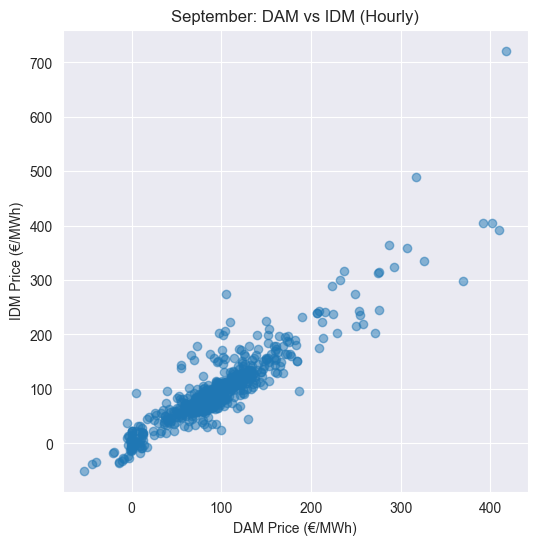

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(mergedS['DAM_price'], mergedS['IDM_price'], alpha=0.5)
plt.title("September: DAM vs IDM (Hourly)")
plt.xlabel("DAM Price (€/MWh)")
plt.ylabel("IDM Price (€/MWh)")
plt.grid(True)
plt.show()

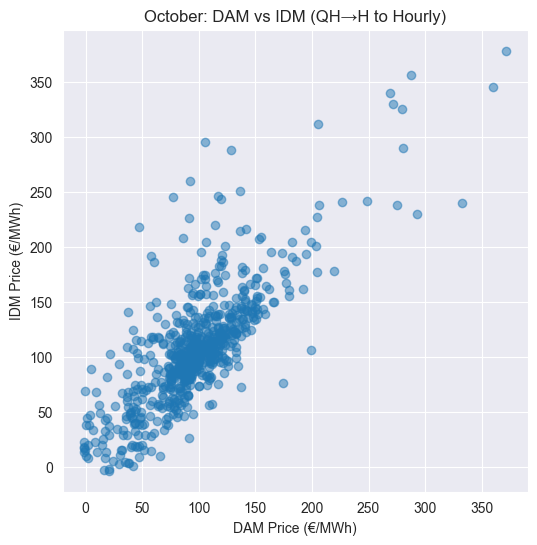

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(mergedOhourly['DAM_price'], mergedOhourly['IDM_price'], alpha=0.5)
plt.title("October: DAM vs IDM (QH→H to Hourly)")
plt.xlabel("DAM Price (€/MWh)")
plt.ylabel("IDM Price (€/MWh)")
plt.grid(True)
plt.show()

Pre tento výpočet som agregoval 15 minutové periódy do korešpondujúcich hodín aby som to mohol porovnať s IDM čo zníži koreláciu medzi DAM a IDM. Po prechode z 1 hodinovej periódy na 15 minutové, padla sila korelácie medzi DAM a IDM čo znázorňuje že trh je viac volatilný.

Deviation calculation

In [8]:
mergedS['abs_dev'] = (mergedS['DAM_price'] - mergedS['IDM_price']).abs()
print("September")
print("mean: " + str(mergedS['abs_dev'].mean()))
print("median: " + str(mergedS['abs_dev'].median()))
print("std: " + str(mergedS['abs_dev'].std()))

mergedOhourly['abs_dev'] = (
    mergedOhourly['DAM_price'] - mergedOhourly['IDM_price']
).abs()
print("")
print("October")
print("mean: " + str(mergedOhourly['abs_dev'].mean()))
print("median: " + str(mergedOhourly['abs_dev'].median()))
print("std: " + str(mergedOhourly['abs_dev'].std()))

September
mean: 15.354861111111111
median: 8.644999999999996
std: 22.02829191664905

October
mean: 21.43197510094213
median: 12.55749999999999
std: 25.72313671207968


Priemer aj medián sa zvýšili v októbri čo znamená že rozlišnosť medzi DAM a IDM sa zväčšila.

Štandardná odchylka sa taktiež zväčšila čo naznačuje že trh sa stal viac volatilný a nepredvídateľný.

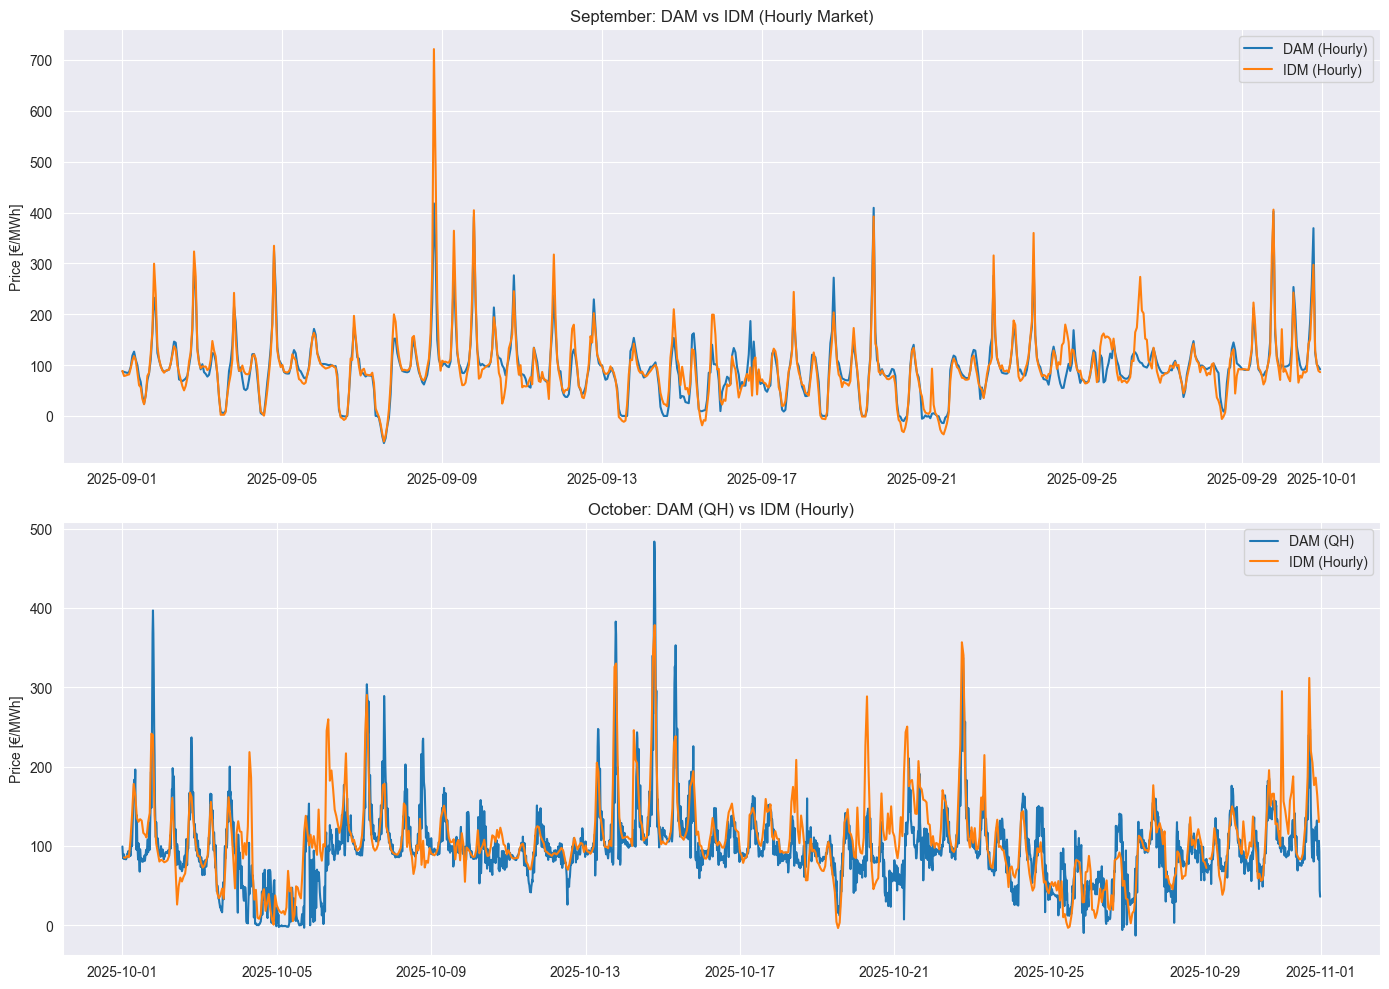

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# --- September (Hourly) ---
ax[0].plot(mergedS['deliveryStartBA'], mergedS['DAM_price'], label='DAM (Hourly)')
ax[0].plot(mergedS['deliveryStartBA'], mergedS['IDM_price'], label='IDM (Hourly)')
ax[0].set_title("September: DAM vs IDM (Hourly Market)")
ax[0].set_ylabel("Price [€/MWh]")
ax[0].legend()
ax[0].grid(True)

# --- October (QH DAM vs Hourly IDM) ---
ax[1].plot(octoberDAM['deliveryStartBA'], octoberDAM['price'], label='DAM (QH)')
ax[1].plot(octoberIDM['deliveryStartBA'], octoberIDM['priceWeightedAverage'], label='IDM (Hourly)')
ax[1].set_title("October: DAM (QH) vs IDM (Hourly)")
ax[1].set_ylabel("Price [€/MWh]")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


V septembri IDM náusleduje DAM o dosť presnejšie pričom v októbri až tak moc nie. Je možné že časť tejto odchylky je z dôvodu že IDM má iba average hourly price.

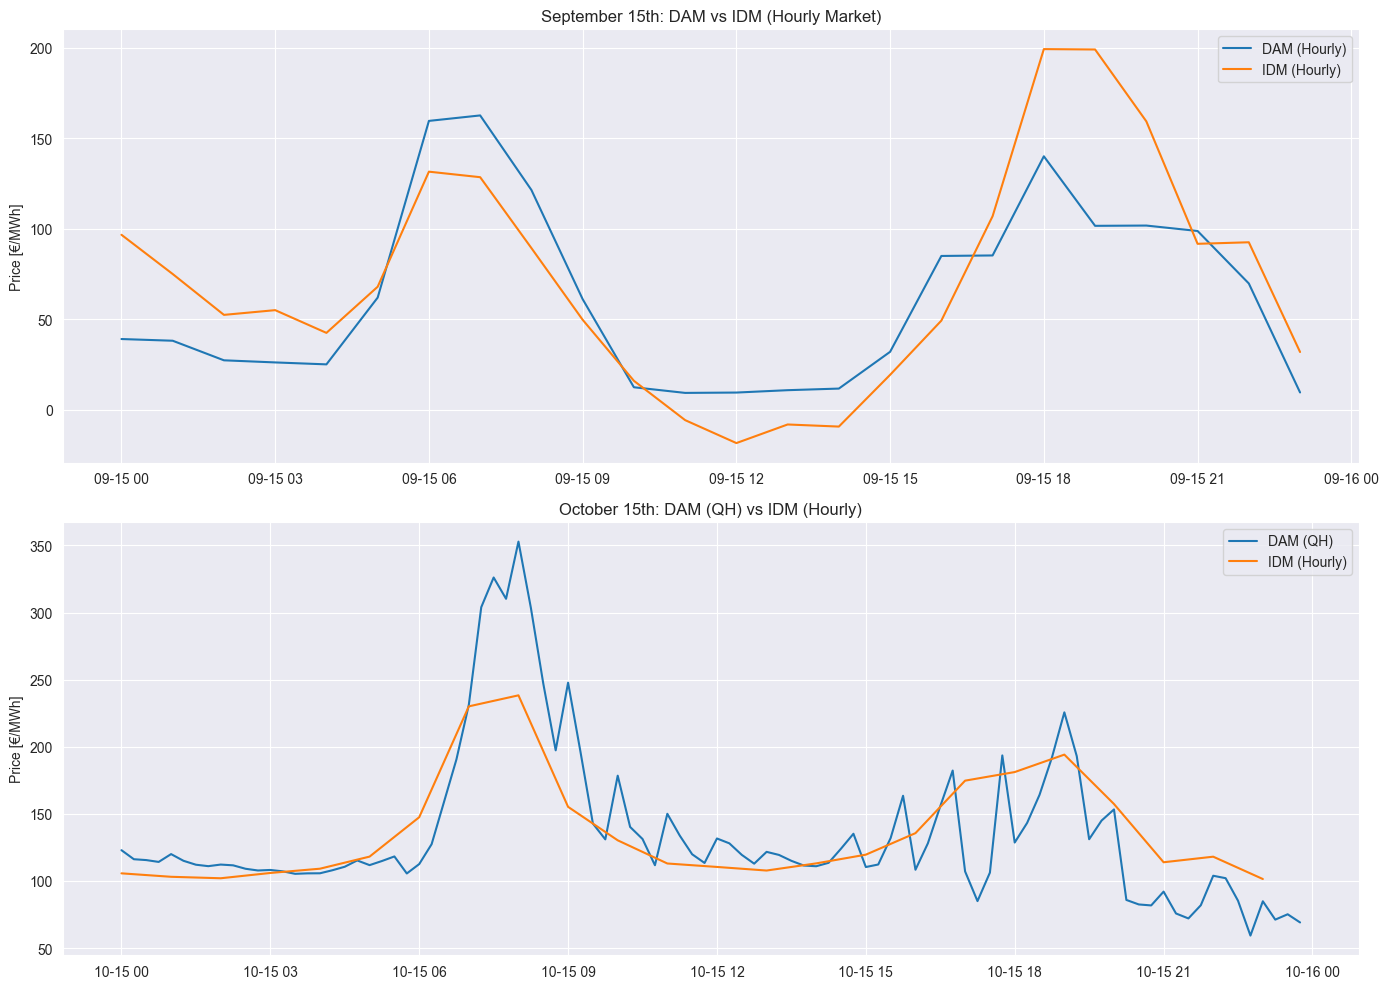

In [10]:
date_sep = "2025-09-15"
date_oct = "2025-10-15"

dayS = mergedS[
    mergedS['deliveryStartBA'].dt.date == pd.to_datetime(date_sep).date()
]

dayOD = octoberDAM[
    octoberDAM['deliveryStartBA'].dt.date == pd.to_datetime(date_oct).date()
]
dayOI = octoberIDM[
    octoberIDM['deliveryStartBA'].dt.date == pd.to_datetime(date_oct).date()
]


fig2, ax2 = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# --- September (Hourly) ---
ax2[0].plot(dayS['deliveryStartBA'], dayS['DAM_price'], label='DAM (Hourly)')
ax2[0].plot(dayS['deliveryStartBA'], dayS['IDM_price'], label='IDM (Hourly)')
ax2[0].set_title("September 15th: DAM vs IDM (Hourly Market)")
ax2[0].set_ylabel("Price [€/MWh]")
ax2[0].legend()
ax2[0].grid(True)

# --- October (QH DAM vs Hourly IDM) ---
ax2[1].plot(dayOD['deliveryStartBA'], dayOD['price'], label='DAM (QH)')
ax2[1].plot(dayOI['deliveryStartBA'], dayOI['priceWeightedAverage'], label='IDM (Hourly)')
ax2[1].set_title("October 15th: DAM (QH) vs IDM (Hourly)")
ax2[1].set_ylabel("Price [€/MWh]")
ax2[1].legend()
ax2[1].grid(True)

plt.tight_layout()
plt.show()

absolute deviation

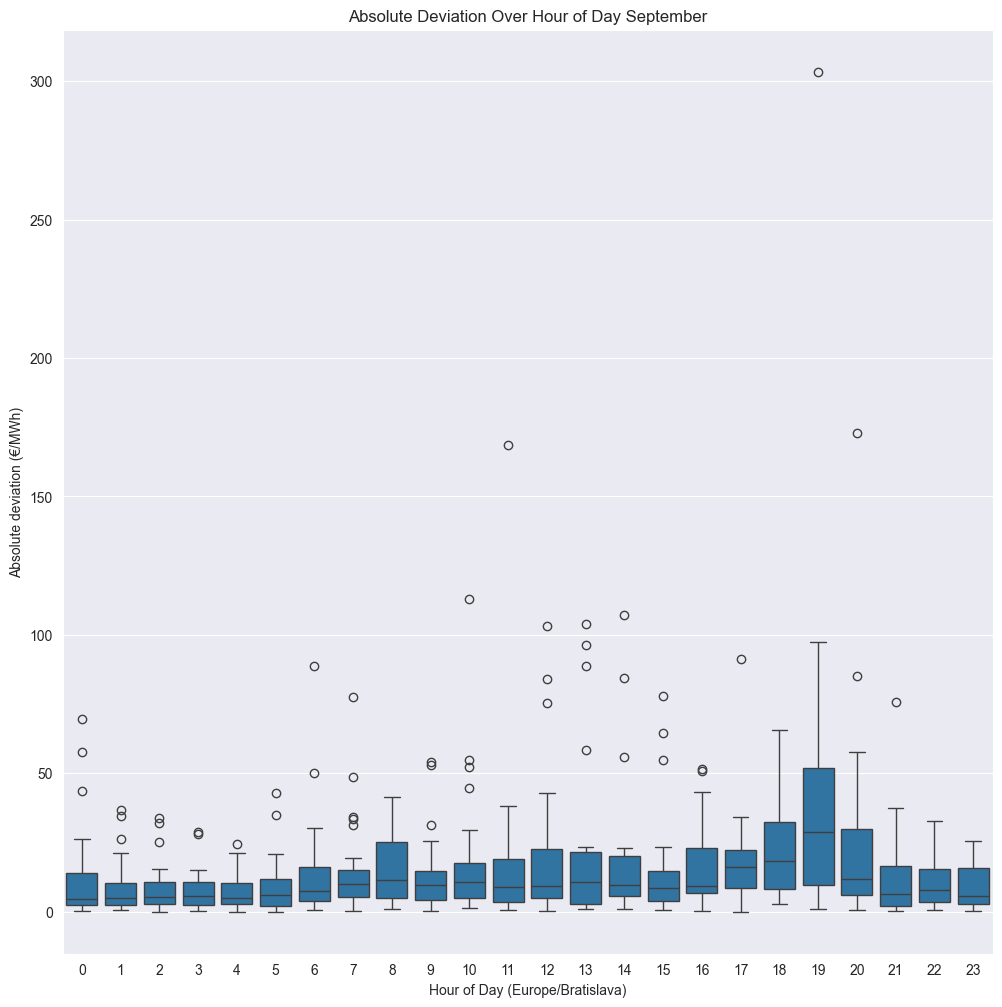

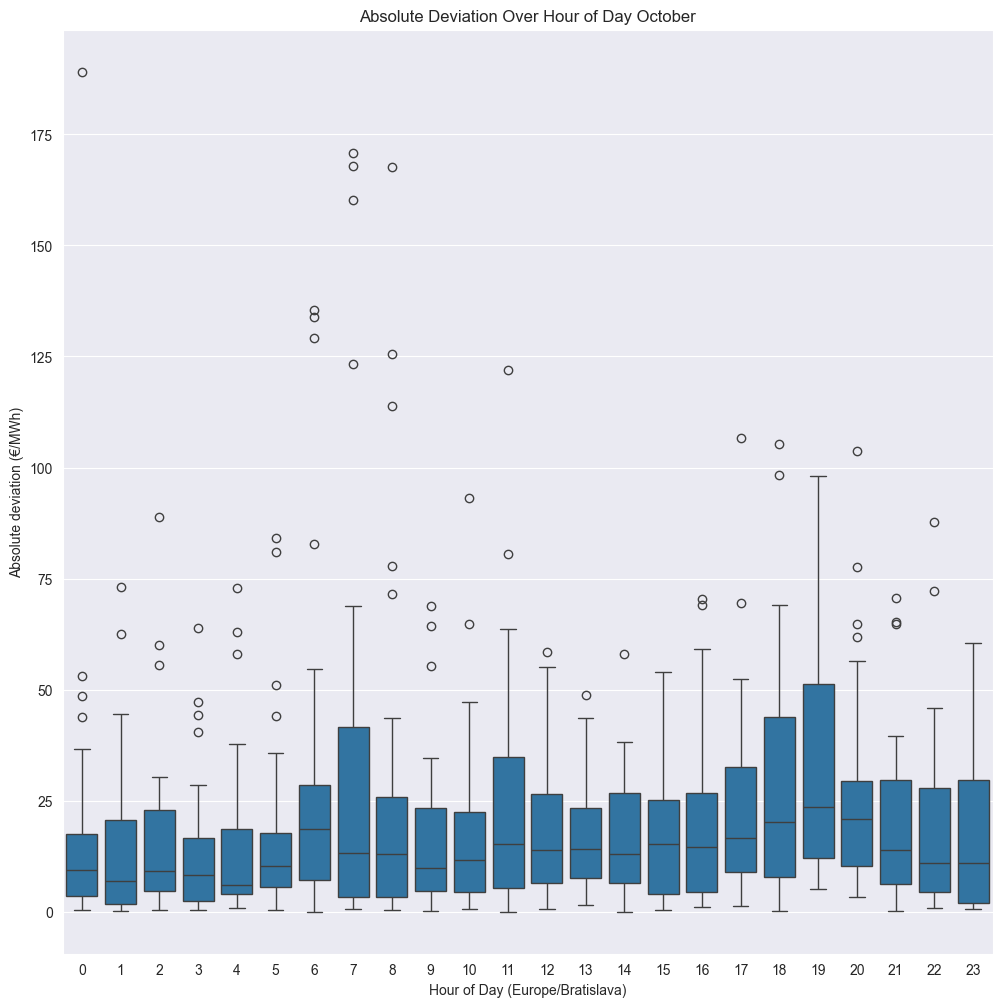

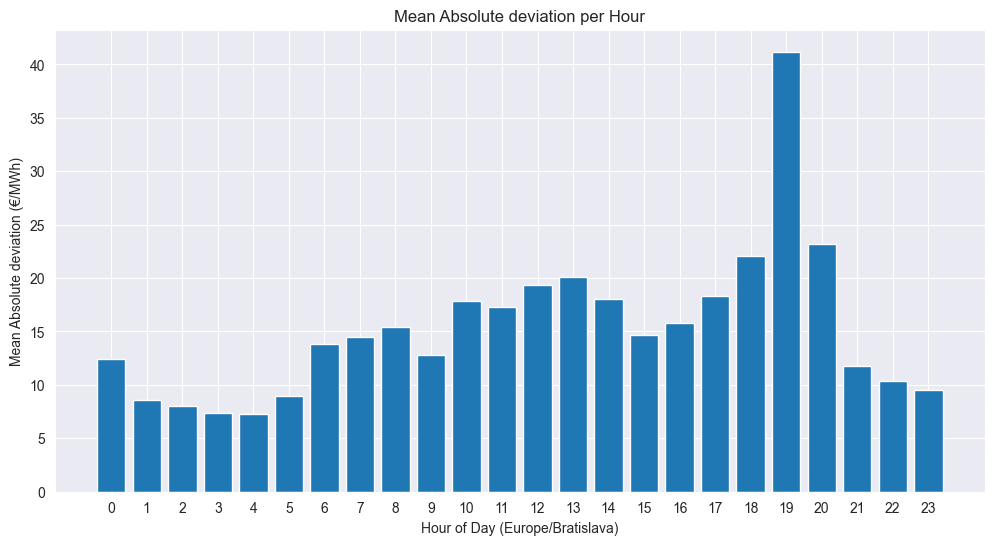

In [11]:
import seaborn as sns
mergedS['hour'] = mergedS['deliveryStartBA'].dt.hour
plt.figure(figsize=(12,12))
sns.boxplot(data=mergedS, x='hour', y='abs_dev')
plt.title('Absolute Deviation Over Hour of Day September')
plt.suptitle("")   # remove automatic pandas title
plt.xlabel('Hour of Day (Europe/Bratislava)')
plt.ylabel('Absolute deviation (€/MWh)')
plt.show()

mergedOhourly['hour'] = mergedOhourly['deliveryStartBA'].dt.hour
plt.figure(figsize=(12,12))
sns.boxplot(data=mergedOhourly, x='hour', y='abs_dev')
plt.title('Absolute Deviation Over Hour of Day October')
plt.suptitle("")   # remove automatic pandas title
plt.xlabel('Hour of Day (Europe/Bratislava)')
plt.ylabel('Absolute deviation (€/MWh)')
plt.show()

hour_mean = mergedS.groupby('hour')['abs_dev'].mean()

plt.figure(figsize=(12,6))
plt.bar(hour_mean.index, hour_mean.values)
plt.xlabel('Hour of Day (Europe/Bratislava)')
plt.ylabel('Mean Absolute deviation (€/MWh)')
plt.title('Mean Absolute deviation per Hour')
plt.xticks(range(24))
plt.show()

rozdiely medzi IDM a DAM sú najväčšie 19teho v danom mesiaci a potom zaujímavý menší skok okolo 7meho dňa. Celkovo ako sme už predtým zistili sa odchylka z mesiaca zvýšila kvôl

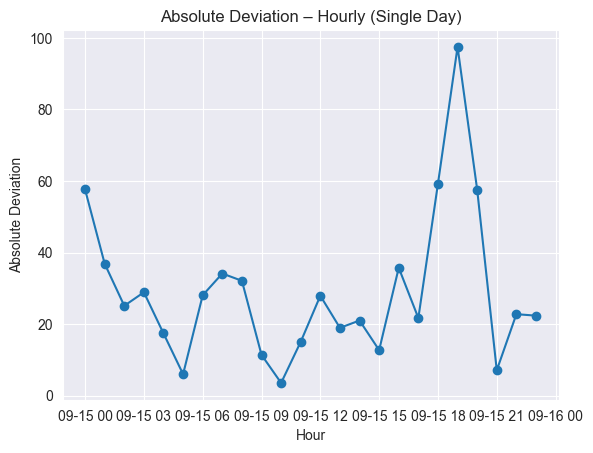

In [12]:
plt.plot(dayS['deliveryStartBA'], dayS['abs_dev'], marker='o')
plt.title("Absolute Deviation – Hourly (Single Day)")
plt.xlabel("Hour")
plt.ylabel("Absolute Deviation")
plt.grid(True)
plt.show()

remaking average price

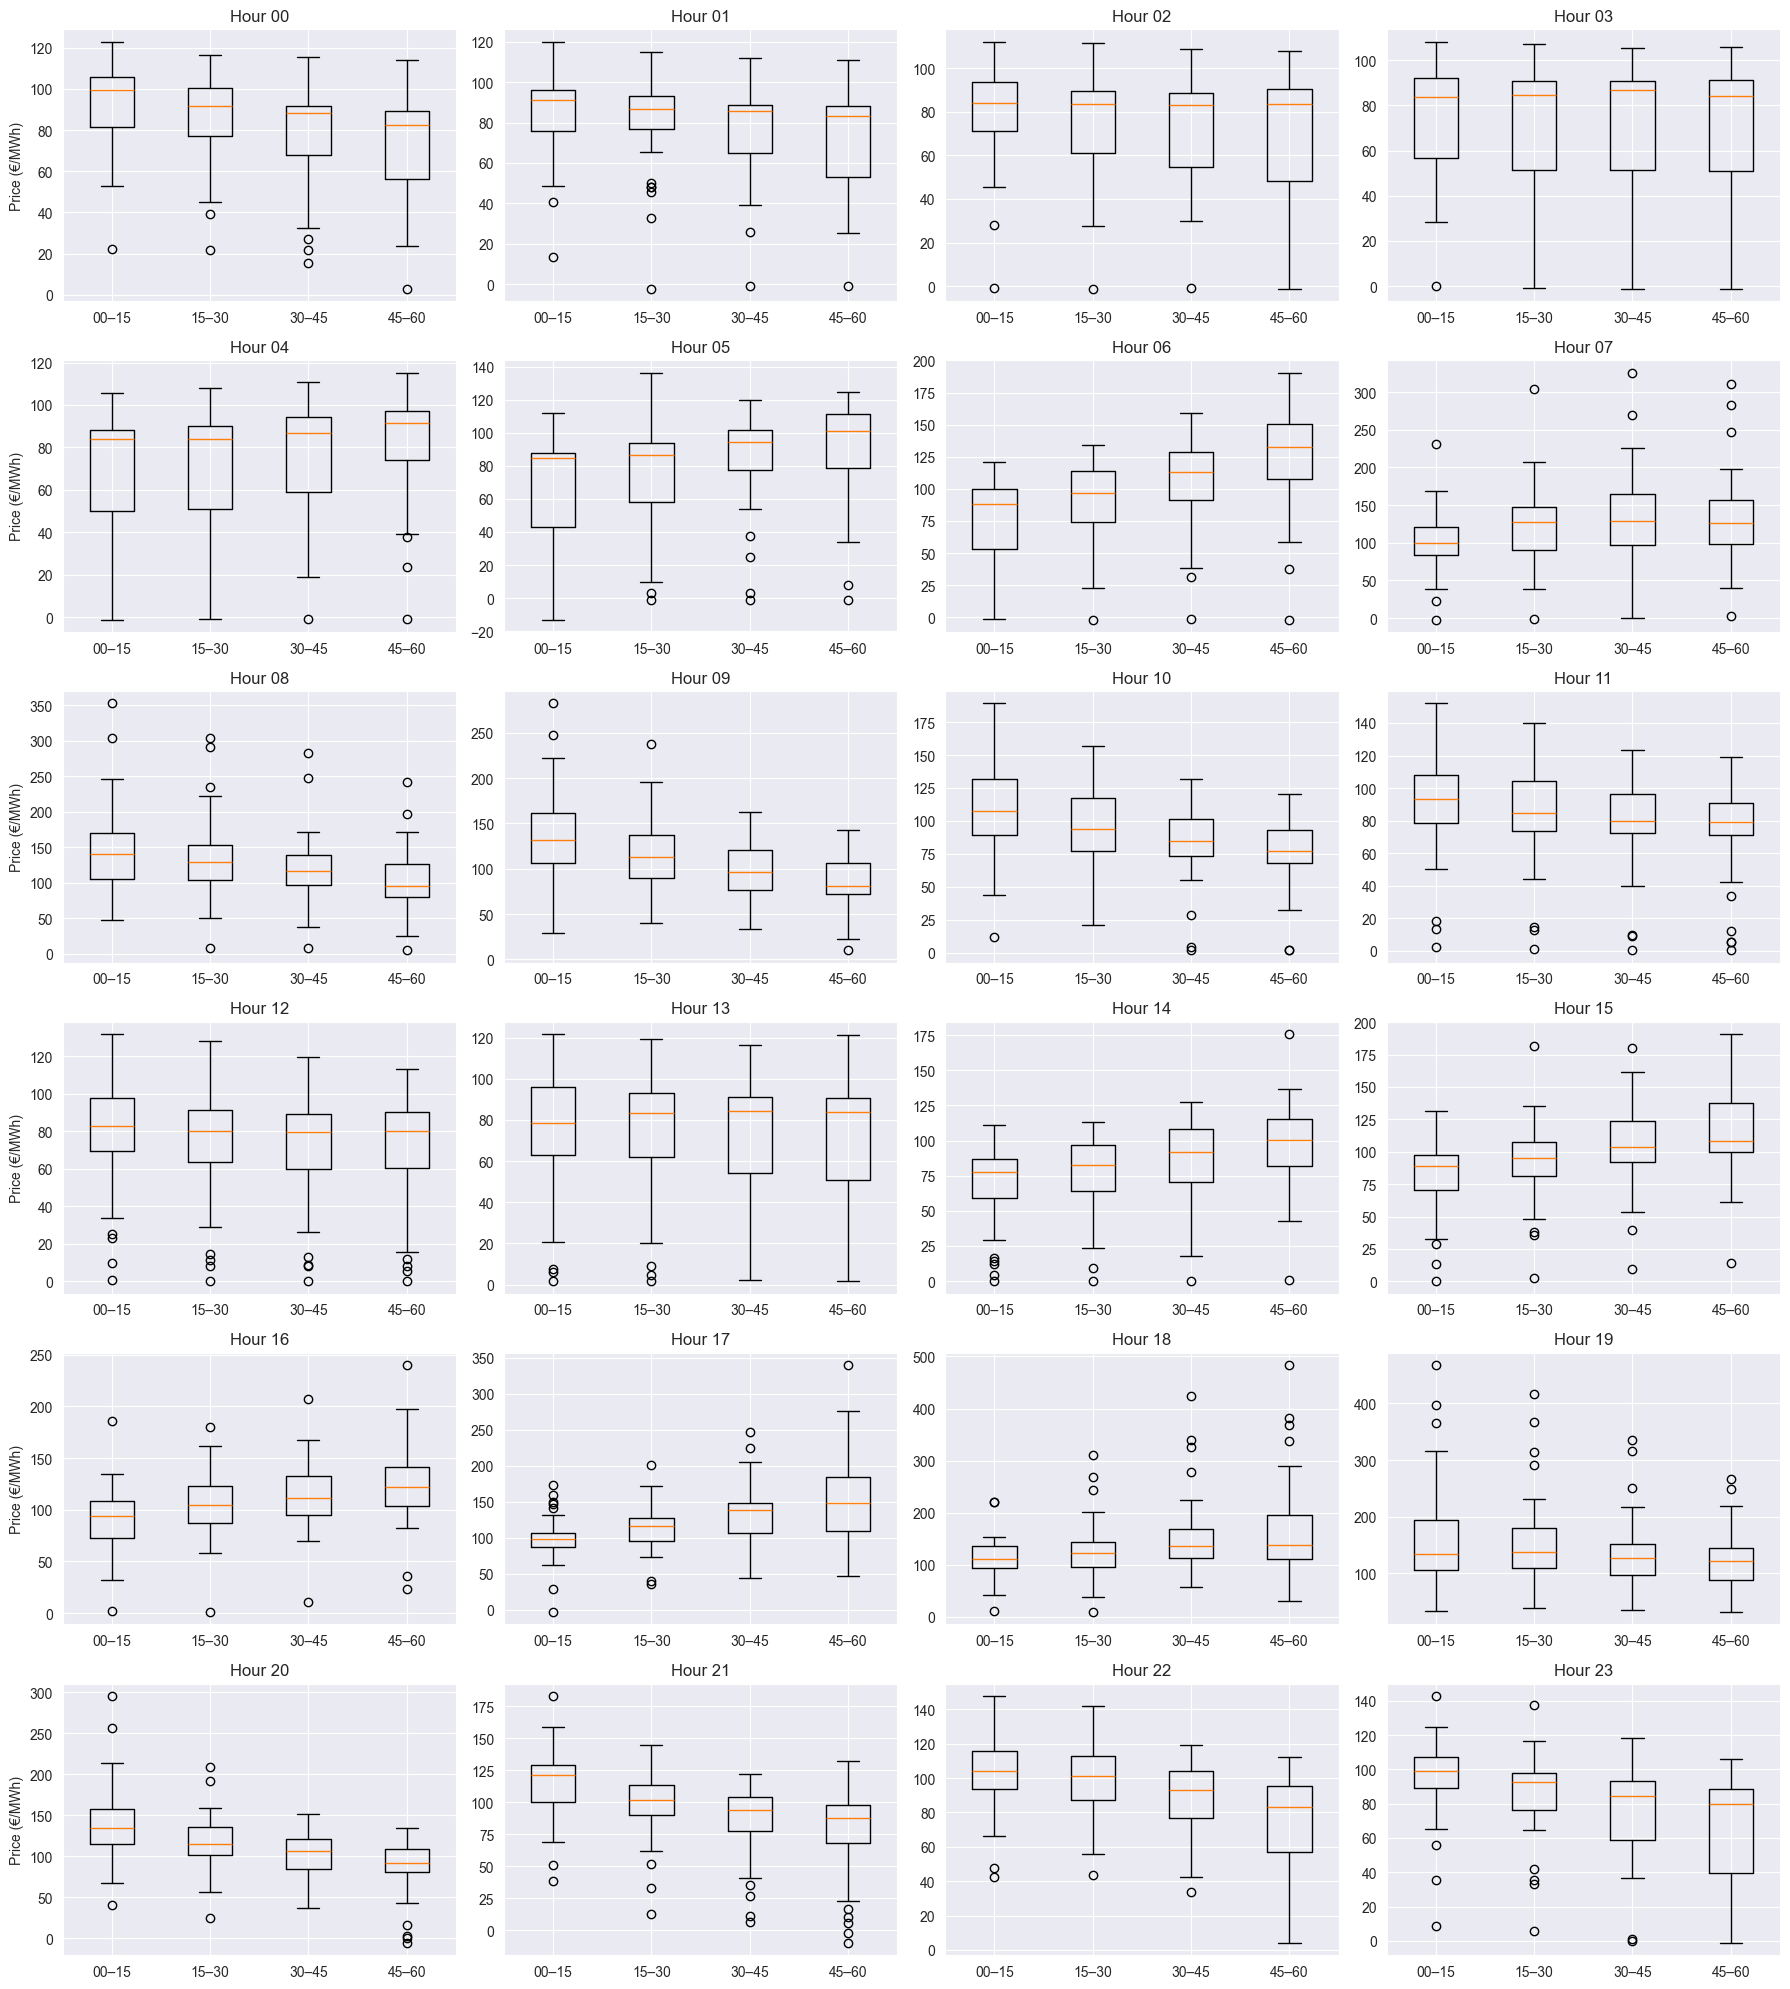

In [13]:
hours = range(24)
octoberDAM['minute'] = octoberDAM['deliveryStartBA'].dt.minute
octoberDAM['quarter'] = octoberDAM['minute'] // 15
octoberDAM['hour'] = octoberDAM['deliveryStartBA'].dt.hour
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()


for i, hour in enumerate(hours):
    ax = axes[i]

    subset = octoberDAM[octoberDAM['hour'] == hour]
    data = [
        subset[subset['quarter'] == q]['price'].dropna()
        for q in range(4)
    ]

    ax.boxplot(data)
    ax.set_title(f'Hour {hour:02d}')
    ax.set_xticklabels(['00–15', '15–30', '30–45', '45–60'], rotation=0)

    if i % 4 == 0:
        ax.set_ylabel('Price (€/MWh)')
    ax.grid(True)

plt.tight_layout()
plt.show()